In [1]:
import zipfile

zip_path = "statlog+german+credit+data.zip"        # your zip file name
extract_path = "C:/Users/Roger Lerin Dyriam/Documents/research_paper/statlog+german+credit+data"   # folder where files will be extracted

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed!")

Extraction completed!


In [2]:
# Import Required Libraries
import os
import warnings
warnings.filterwarnings("ignore")

In [3]:
# Core libraries
import numpy as np
import pandas as pd

In [4]:
# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Plot settings for better readability
plt.style.use("seaborn-v0_8")
sns.set_context("notebook")

### Load the Dataset

In [7]:
# Path to the dataset file
file_path = "C:/Users/Roger Lerin Dyriam/Documents/research_paper/statlog+german+credit+data/german.data"

In [8]:
# Column names as provided in dataset documentation
column_names = [
    "Status_Checking_Account",
    "Duration_Months",
    "Credit_History",
    "Purpose",
    "Credit_Amount",
    "Savings_Account",
    "Employment_Since",
    "Installment_Rate",
    "Personal_Status_Sex",
    "Other_Debtors",
    "Residence_Since",
    "Property",
    "Age",
    "Other_Installment_Plans",
    "Housing",
    "Existing_Credits",
    "Job",
    "Num_Dependents",
    "Telephone",
    "Foreign_Worker",
    "Target"
]

In [9]:
# Dataset is space-separated and has no header
df = pd.read_csv("C:/Users/Roger Lerin Dyriam/Documents/research_paper/statlog+german+credit+data/german.data", sep=r"\s+", header=None)
df.columns = column_names

### Initial Data Inspection

In [11]:
print("\nFirst 5 Rows:")
df.head()


First 5 Rows:


,Status_Checking_Account,Duration_Months,Credit_History,Purpose,Credit_Amount,Savings_Account,Employment_Since,Installment_Rate,Personal_Status_Sex,Other_Debtors,...,Property,Age,Other_Installment_Plans,Housing,Existing_Credits,Job,Num_Dependents,Telephone,Foreign_Worker,Target
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [12]:
print("\nLast 5 Rows:")
df.tail()


Last 5 Rows:


,Status_Checking_Account,Duration_Months,Credit_History,Purpose,Credit_Amount,Savings_Account,Employment_Since,Installment_Rate,Personal_Status_Sex,Other_Debtors,...,Property,Age,Other_Installment_Plans,Housing,Existing_Credits,Job,Num_Dependents,Telephone,Foreign_Worker,Target
995,A14,12,A32,A42,1736,A61,A74,3,A92,A101,...,A121,31,A143,A152,1,A172,1,A191,A201,1
996,A11,30,A32,A41,3857,A61,A73,4,A91,A101,...,A122,40,A143,A152,1,A174,1,A192,A201,1
997,A14,12,A32,A43,804,A61,A75,4,A93,A101,...,A123,38,A143,A152,1,A173,1,A191,A201,1
998,A11,45,A32,A43,1845,A61,A73,4,A93,A101,...,A124,23,A143,A153,1,A173,1,A192,A201,2
999,A12,45,A34,A41,4576,A62,A71,3,A93,A101,...,A123,27,A143,A152,1,A173,1,A191,A201,1


In [13]:
print("\nShape of Dataset:")
print(df.shape)


Shape of Dataset:
(1000, 21)


In [14]:
print("\nData Types:")
print(df.dtypes)


Data Types:
Status_Checking_Account    object
Duration_Months             int64
Credit_History             object
Purpose                    object
Credit_Amount               int64
Savings_Account            object
Employment_Since           object
Installment_Rate            int64
Personal_Status_Sex        object
Other_Debtors              object
Residence_Since             int64
Property                   object
Age                         int64
Other_Installment_Plans    object
Housing                    object
Existing_Credits            int64
Job                        object
Num_Dependents              int64
Telephone                  object
Foreign_Worker             object
Target                      int64
dtype: object


In [15]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Status_Checking_Account    0
Duration_Months            0
Credit_History             0
Purpose                    0
Credit_Amount              0
Savings_Account            0
Employment_Since           0
Installment_Rate           0
Personal_Status_Sex        0
Other_Debtors              0
Residence_Since            0
Property                   0
Age                        0
Other_Installment_Plans    0
Housing                    0
Existing_Credits           0
Job                        0
Num_Dependents             0
Telephone                  0
Foreign_Worker             0
Target                     0
dtype: int64


In [16]:
print("\nTarget Distribution:")
df["Target"].value_counts()


Target Distribution:


Target
1    700
2    300
Name: count, dtype: int64

In [17]:
# Convert target for easier interpretation
# 1 = Good, 2 = Bad  → Convert to Good(0), Bad(1)
df["Target"] = df["Target"].map({1: 0, 2: 1})

In [18]:
print("Updated Target Distribution (0 = Good, 1 = Bad):")
df["Target"].value_counts()

Updated Target Distribution (0 = Good, 1 = Bad):


Target
0    700
1    300
Name: count, dtype: int64

In [19]:
# Data Statistical summary
print("\nStatistical Summary (Numerical Features):")
df.describe()


Statistical Summary (Numerical Features):


,Duration_Months,Credit_Amount,Installment_Rate,Residence_Since,Age,Existing_Credits,Num_Dependents,Target
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000,0.300000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086,0.458487
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000,0.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000,0.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000,0.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000,1.000000


### Exploratory Data Analysis

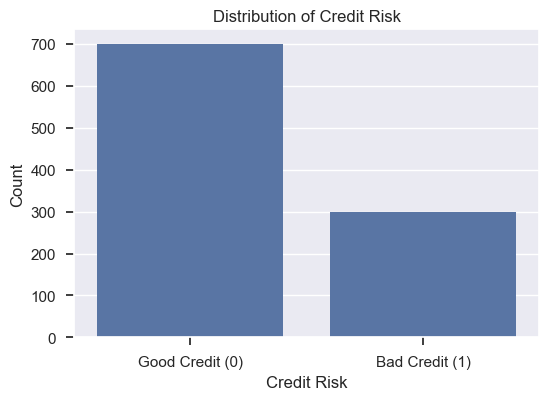

In [21]:
# Target Distribution
plt.figure(figsize=(6,4))
sns.countplot(x="Target", data=df)
plt.title("Distribution of Credit Risk")
plt.xticks([0,1], ["Good Credit (0)", "Bad Credit (1)"])
plt.xlabel("Credit Risk")
plt.ylabel("Count")
plt.show()

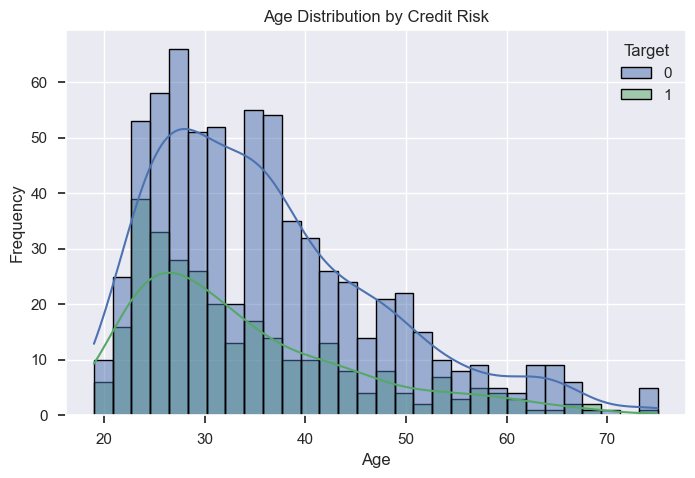

In [22]:
# Age Distribution by Credit Risk
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="Age", hue="Target", bins=30, kde=True)
plt.title("Age Distribution by Credit Risk")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

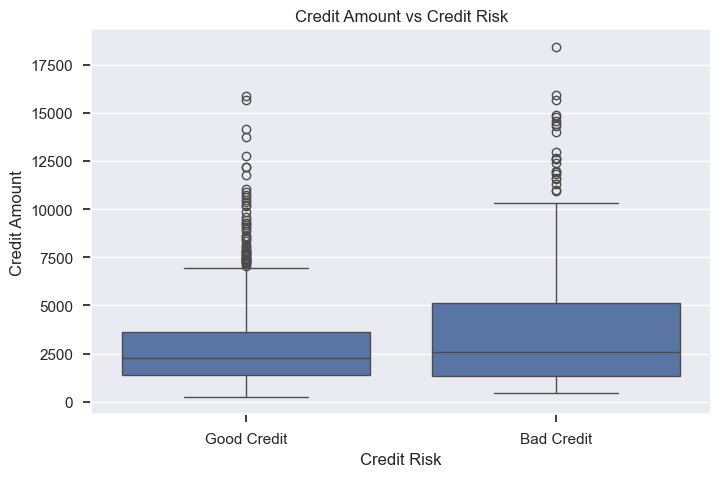

In [23]:
# Credit Amount vs Target
plt.figure(figsize=(8,5))
sns.boxplot(x="Target", y="Credit_Amount", data=df)
plt.title("Credit Amount vs Credit Risk")
plt.xticks([0,1], ["Good Credit", "Bad Credit"])
plt.xlabel("Credit Risk")
plt.ylabel("Credit Amount")
plt.show()

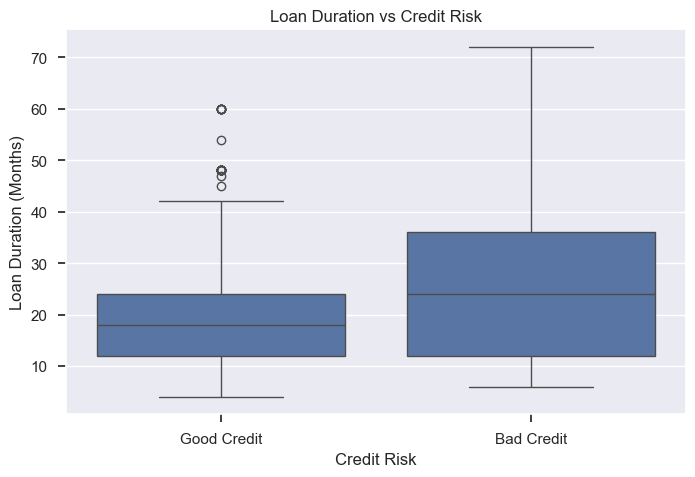

In [24]:
# Loan Duration vs Target
plt.figure(figsize=(8,5))
sns.boxplot(x="Target", y="Duration_Months", data=df)
plt.title("Loan Duration vs Credit Risk")
plt.xticks([0,1], ["Good Credit", "Bad Credit"])
plt.xlabel("Credit Risk")
plt.ylabel("Loan Duration (Months)")
plt.show()

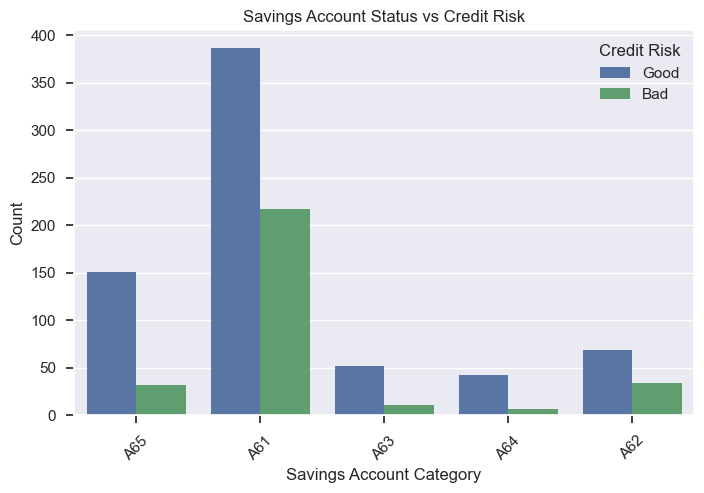

In [25]:
# Savings Account Status vs Target
plt.figure(figsize=(8,5))
sns.countplot(x="Savings_Account", hue="Target", data=df)
plt.title("Savings Account Status vs Credit Risk")
plt.xlabel("Savings Account Category")
plt.ylabel("Count")
plt.legend(title="Credit Risk", labels=["Good", "Bad"])
plt.xticks(rotation=45)
plt.show()

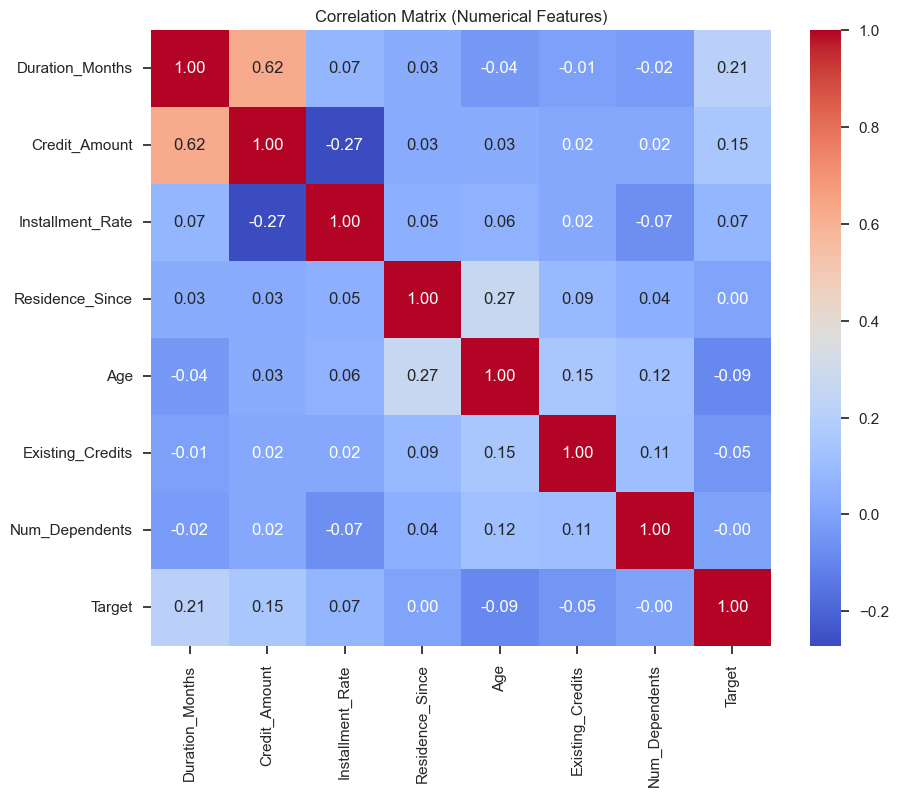

In [26]:
# Correlation Heatmap
# Select numeric columns only
numeric_cols = df.select_dtypes(include=[np.number])

plt.figure(figsize=(10,8))
sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix (Numerical Features)")
plt.show()